In [1]:
from vnstock_forecast.data.query import query_latest, query_ohlcv_grouped
from vnstock_forecast.utils import time_utils
from vnstock_forecast.config import load_config

In [2]:
cfg = load_config()
symbols = cfg.data.updater.symbols

In [3]:
data = query_ohlcv_grouped(symbols=symbols, from_ts=time_utils.time_to_timestamp("01-01-2023"), to_ts=time_utils.time_to_timestamp("05-03-2026"), resolutions=["D"])

In [14]:
from vnstock_forecast.backtest import BacktestEngine
from vnstock_forecast.analysis import AnalysisBot
from vnstock_forecast.analysis.techniques import MACDCrossover, RSICrossover, SMACrossover
bot = AnalysisBot(
    allocation=0.1
)
# bot.add_technique(SMACrossover())
bot.add_technique(MACDCrossover())
# bot.add_technique(RSICrossover())


In [15]:

engine = BacktestEngine(initial_cash=100_000_000)
report = engine.run(bot=bot, data=data["D"], start="2023-01-01", end="2026-03-05")
report.print_summary()

  BACKTEST REPORT: AnalysisBot
  Symbols:        ACB, BID, CTG, DGC, FPT, GAS, GVR, HDB, HPG, LPB, MBB, MSN, MWG, PLX, SAB, SHB, SSB, SSI, STB, TCB, TPB, VCB, VHM, VIB, VIC, VJC, VNM, VPB, VPL, VRE
  Period:         2023-01-03 → 2026-03-05
  Commission:     0.15%
------------------------------------------------------------
  Initial Cash:       100,000,000
  Final Equity:       126,306,462
  Total PnL:           38,366,869
  Total Return:            26.31%
------------------------------------------------------------
  Trades:                     762
  Wins:                       335
  Losses:                     427
  Win Rate:                 44.0%
  Avg Win:                  6.45%
  Avg Loss:                -3.29%
  R:R Ratio:                 1.96
  Max Drawdown:             8.35%
------------------------------------------------------------
  Close Reasons:  {'take_profit': 178, 'manual': 503, 'stop_loss': 81, 'end_of_data': 6}


In [13]:
report.trade_history()

,id,symbol,entry_time,exit_time,entry_price,exit_price,quantity,stop_loss,take_profit,pnl,pnl_pct,close_reason
0,289d3e45,VHM,2023-02-20,2023-02-23,45200.0000,42036.00,176,42036.00,49720.00,-556864.0,-7.00,stop_loss
1,9fa65874,VPB,2023-02-15,2023-03-13,15154.5760,16670.03,659,14093.76,16670.03,998684.0,10.00,take_profit
2,16797ce2,VRE,2023-02-28,2023-03-13,26700.0000,29370.00,267,24831.00,29370.00,712890.0,10.00,take_profit
3,98b4e978,VHM,2023-03-06,2023-03-15,42100.0000,46310.00,85,39153.00,46310.00,357850.0,10.00,take_profit
4,817e42b3,MWG,2023-03-01,2023-03-21,39524.7552,36758.02,126,36758.02,43477.23,-348609.0,-7.00,stop_loss
...,...,...,...,...,...,...,...,...,...,...,...,...
269,28932796,ACB,2026-02-11,2026-03-05,23650.0000,23550.00,311,21994.50,26015.00,-31100.0,-0.42,end_of_data
270,5d526e10,CTG,2026-02-11,2026-03-05,37900.0000,36200.00,194,35247.00,41690.00,-329800.0,-4.49,end_of_data
271,a5678924,SHB,2026-02-11,2026-03-05,15500.0000,15250.00,475,14415.00,17050.00,-118750.0,-1.61,end_of_data
272,2f11af24,VCB,2026-02-11,2026-03-05,64700.0000,62500.00,113,60171.00,71170.00,-248600.0,-3.40,end_of_data


In [16]:
report.event_log()

,timestamp,action,symbol,price,quantity,position_id,equity,reason
0,2023-03-06,buy,VHM,42100.0000,237,4f2cd54b,9.998503e+07,"[macd_crossover] MACD(12,26,9) bullish crossov..."
1,2023-03-06,buy,VIC,26300.0000,380,a14d325f,9.997004e+07,"[macd_crossover] MACD(12,26,9) bullish crossov..."
2,2023-03-06,buy,VPB,15066.4680,663,ddb363d4,9.995506e+07,"[macd_crossover] MACD(12,26,9) bullish crossov..."
3,2023-03-07,buy,BID,34020.4158,205,2d2979e1,1.001862e+08,"[macd_crossover] MACD(12,26,9) bullish crossov..."
4,2023-03-08,buy,CTG,18048.1014,349,e08e9961,1.008473e+08,"[macd_crossover] MACD(12,26,9) bullish crossov..."
...,...,...,...,...,...,...,...,...
1531,2026-03-05,end_of_data,STB,64900.0000,52,2de5294d,1.263463e+08,Đóng cuối kỳ backtest
1532,2026-03-05,end_of_data,GVR,40550.0000,101,a8f92bb7,1.263401e+08,Đóng cuối kỳ backtest
1533,2026-03-05,end_of_data,PLX,64700.0000,101,abb593fb,1.263303e+08,Đóng cuối kỳ backtest
1534,2026-03-05,end_of_data,GAS,119700.0000,59,0071d183,1.263197e+08,Đóng cuối kỳ backtest


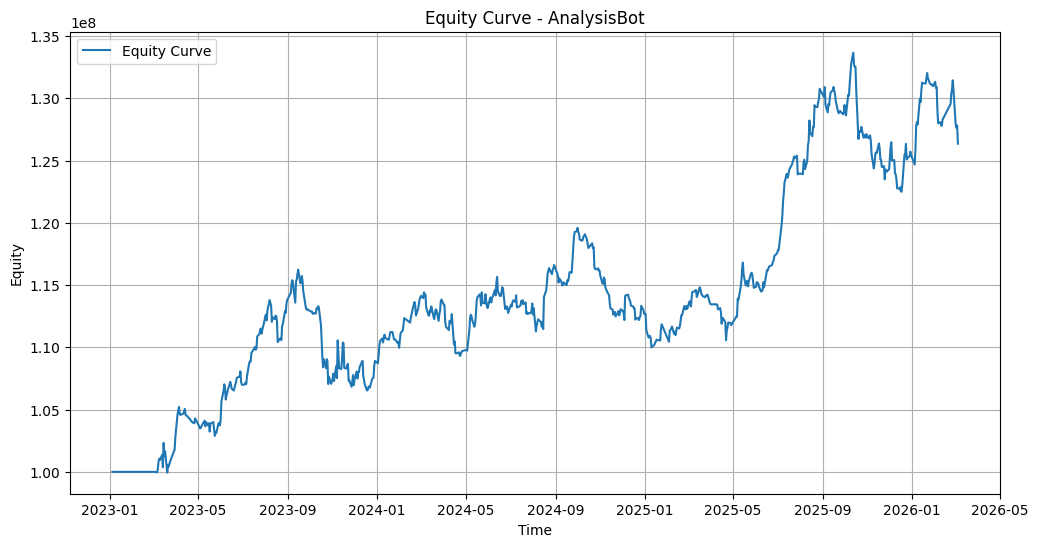

In [17]:
report.plot_equity()